In [257]:
from pathlib import Path
import pandas as pd
from atmdp003.utils.config import PREPROCESSED_DIR_PATH, COMBINED_CSV_PATH

preprocessed_dir_path = PREPROCESSED_DIR_PATH()
combined_csv_path = COMBINED_CSV_PATH()

KEY_WINTER = "winter"
KEY_SPRING = "spring"
KEY_SUMMER = "summer"
KEY_AUTUMN = "autumn"

SEASONS = [KEY_WINTER, KEY_SPRING, KEY_SUMMER, KEY_AUTUMN]

MONTH_SEASON_MAP = {
    1: SEASONS[0],
    2: SEASONS[0],
    3: SEASONS[1],
    4: SEASONS[1],
    5: SEASONS[1],
    6: SEASONS[2],
    7: SEASONS[2],
    8: SEASONS[2],
    9: SEASONS[3],
    10: SEASONS[3],
    11: SEASONS[3],
    12: SEASONS[0]
}

COLS_IGNORE = ["seasonyear", "season"]

In [258]:
path = Path(f"{preprocessed_dir_path}/")
files_to_process = path.glob("*.csv")
dfs = []
for file in files_to_process:
    df = pd.read_csv(file, engine='pyarrow', index_col="Time")
    # df = df[~df.index .duplicated(keep="first")]
    df.sort_index()
    dfs.append(df)

df = pd.concat(dfs, axis=1, sort=True)

df = df.sort_index()
df = df.asfreq("h") # force hourly frequency, including rows with no data


In [259]:
df["season"] = df.index.month.map(MONTH_SEASON_MAP)
df["seasonyear"] = df["seasonyear"] = (df.index + pd.DateOffset(months=1)).year

In [260]:
df.to_csv(f"{combined_csv_path}", index=True, date_format="%Y-%m-%d %H:%M:%S")

**Note:** No data from 2022 for trace gases; winter 2023 had limited number of measurements!

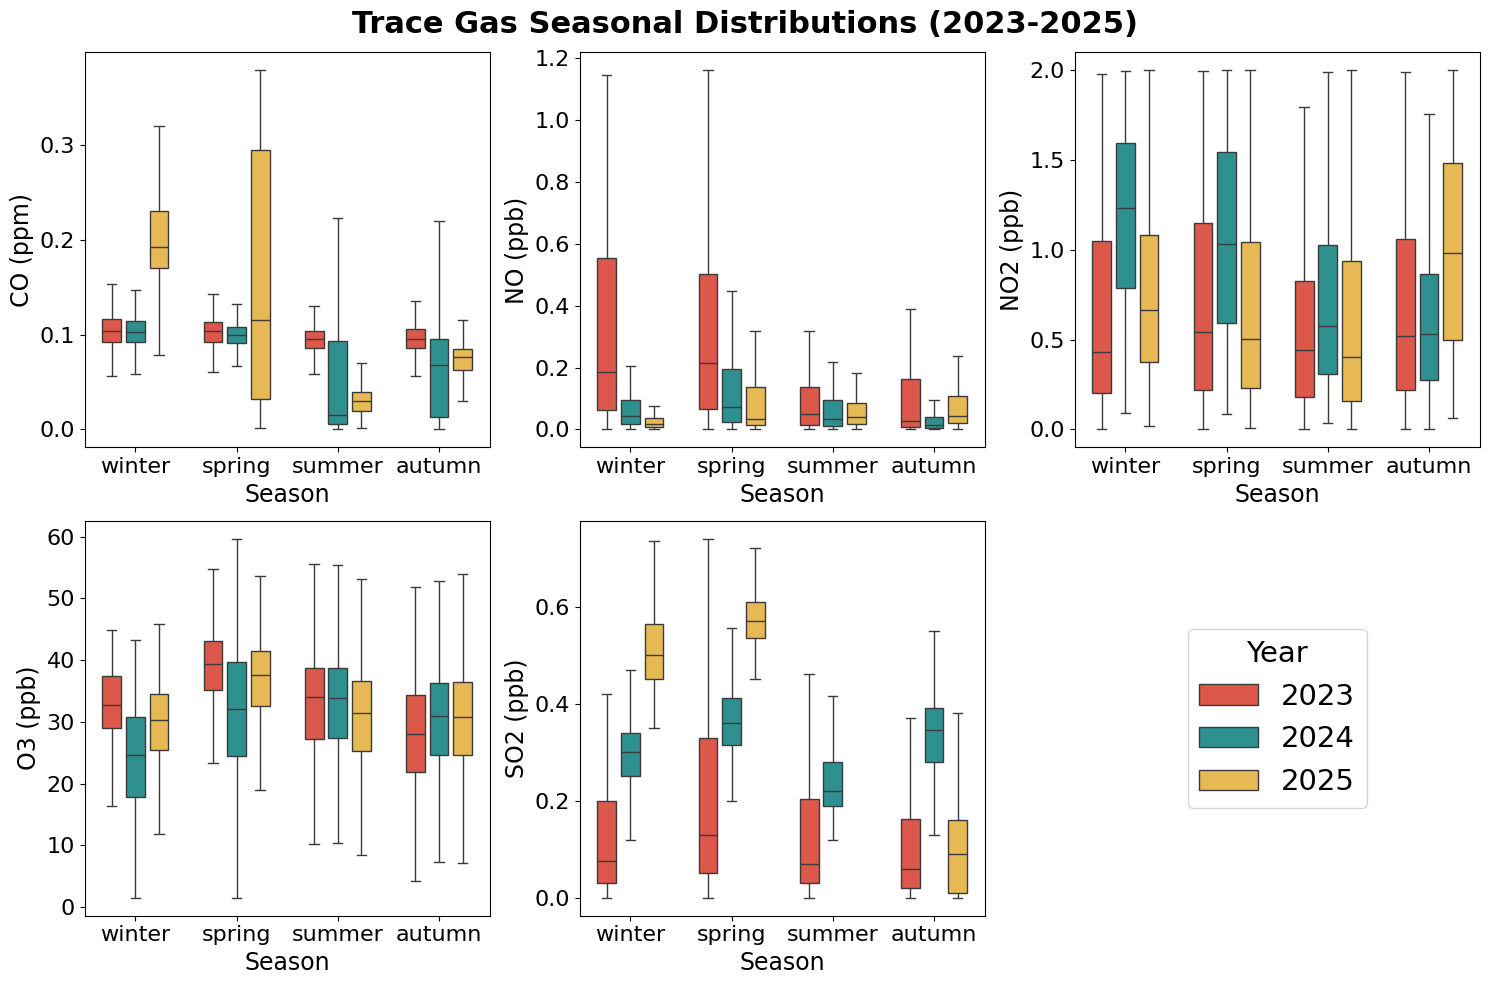

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Trace gases
SEASON_YEARS = [2023, 2024, 2025]
TRACE_GASES_TO_INCLUDE = [
    "CO_ppm", 
    "NO_ppb", 
    "NO2_ppb", 
    "O3_ppb", 
    "SO2_ppb"
    ]

YEAER_PALETTE = {2023: "#f34433", 2024: "#1fa19e", 2025: "#ffc23d"}

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=False)
axes_flat = axes.flatten()

for i, measure in enumerate(TRACE_GASES_TO_INCLUDE):
    df_measure = df[[measure, "season", "seasonyear"]].copy().dropna(subset=[measure])
    parts = measure.split('_')
    measure = f"{parts[0]} ({parts[1]})"
    columns = [measure , "Season", "Year"]
    df_measure.columns = columns
    # plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=df_measure, 
        x='Season', 
        y=measure, 
        hue='Year', 
        palette=YEAER_PALETTE, 
        width=0.7, 
        gap=0.2,
        showfliers=False,
        ax=axes_flat[i]
    )
    axes_flat[i].get_legend().remove()
    axes_flat[i].set_xlabel("Season", fontsize=17)
    axes_flat[i].set_ylabel(measure, fontsize=17)
    axes_flat[i].tick_params(axis='both', labelsize=16)

handles, labels = axes_flat[i].get_legend_handles_labels()
ax_legend = axes_flat[5]
ax_legend.legend(handles, labels, loc='center', title="Year", fontsize=21, title_fontsize=21)
ax_legend.axis('off')

fig.suptitle('Trace Gas Seasonal Distributions (2023-2025)', fontsize=22, fontweight='bold')
plt.tight_layout(h_pad=1.0)
plt.show()
    

